<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/Delta_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delta Method

### 9-28-25

This notebook provides the setup, univariate and multivariate cases, outline of a proof, and demonstrations of the Delta method.

## Setup, Univariate & Multivariate

### 1st Order:

Let $\hat{\theta}_{n}$ be an estimator for $\theta \in \mathbb{R}$ satisfying:

$$
\sqrt{n}(\hat{\theta}_{n} - \theta) \xrightarrow{D} N(0, \sigma^{2})
$$

with finite variance $\sigma^{2}$. Let $g(\theta)$ be a smooth function such that $g'(\theta)\ne 0$. Using a first-order Taylor series approximation,

$$
g(\hat{\theta}_{n}) \approx g(\theta) + g'(\theta)(\hat{\theta}_{n} - \theta)
$$

and re-arranging:

$$
\sqrt{n} \left( g(\hat{\theta}_{n}) - g(\theta) \right) \approx g'(\theta)\sqrt{n}(\hat{\theta}_{n} - \theta)
$$

By Slutsky's theorem,

$$
\sqrt{n} \left( g(\hat{\theta}_{n}) - g(\theta) \right) \xrightarrow{D} N \left( 0, [g'(\theta)]^{2}\sigma^{2}\right)
$$

Thus $g(\hat{\theta}_{n})$ is asymptotically normal with mean $g(\theta)$ and variance $\frac{[g'(\theta)]^{2}\sigma^{2}}{n}$.

### 2nd Order:

Suppose $g'(\theta)=0$ but $g''(\theta) \ne 0$. Using a second-order Taylor expansion:

\begin{align*}
g(\hat{\theta}_{n}) &\approx g(\theta) + g'(\theta)(\hat{\theta}_{n} - \theta) + \frac{1}{2}g''(\theta)(\hat{\theta}_{n} - \theta)^{2} \\
n \left( g(\hat{\theta}_{n}) - g(\theta) \right) &\approx n\frac{1}{2}g''(\theta)(\hat{\theta}_{n} - \theta)^{2}
\end{align*}

Thus
$$
\sqrt{n} ( \hat{\theta}_{n} - \theta ) \xrightarrow{D} N(0,\sigma^{2})
$$
implies

$$
n(g(\hat{\theta}_{n}) - g(\theta) ) \xrightarrow{D}\sigma^{2} \frac{g''(\theta)}{2}\chi_{1}^{2}
$$

### Multivariate:

Let $\hat{\theta}_{n}$ be an estimator of $\theta \in \mathbb{R}^{k}$ and $g: \mathbb{R}^{k} \rightarrow \mathbb{R}^{m}$ differentiable at $\theta$, then $\hat{\theta}_{n}$'s asymptotic distribution

$$
\sqrt{n} (\hat{\theta}_{n} - \theta) \xrightarrow{D} N(0, \Sigma)
$$

and a multivariate Taylor expansion

\begin{align*}
g(\hat{\theta}_{n}) &\approx g(\theta) + \nabla g(\theta)^{T} (\hat{\theta}_{n} - \theta) \\
\end{align*}

imply

\begin{align*}
\text{Var}[g(\hat{\theta}_{n})] &\approx \text{Var}[\nabla g(\theta)^{T}\hat{\theta}_{n}] \\
&\approx\nabla g(\theta)^{T}\text{Var}(\hat{\theta}_{n})\nabla g(\theta)\\
&\approx \nabla g(\theta)^{T}n^{-1}\Sigma\nabla g(\theta)\\
\end{align*}

and

$$
\sqrt{n} \left( g(\hat{\theta}_{n}) - g(\theta) \right) \xrightarrow{D} N(0, \nabla g(\theta)^{T}\Sigma \nabla g(\theta))
$$

## Demonstrations

### Ex.1: Asymptotic Variance of Sample Proportion Logit

Suppose $X_{1}...X_{n} \overset{\text{iid}}{\sim}$ Bernoulli($p$). Let $\hat{p}_{n} = \frac{1}{n}\sum_{i=1}^{n}p$. The sum of i.i.d Bernoullis is Binomial, thus

\begin{align*}
n \hat{p}_{n} &\sim \text{Bin}(n,p) \\
\text{Var}(\hat{p}_{n}) &= \frac{p(1-p)}{n} \\
\end{align*}

By the CLT,

\begin{align*}
\sqrt{n}(\hat{p}_{n} - p) \xrightarrow{D} N(0,p(1-p))
\end{align*}

Let $g(p) = \text{log}(\frac{p}{1-p})$:

\begin{align*}
g'(p) &= \frac{1-p}{p}\times \frac{(1-p)-p(-1)}{(1-p)^{2}} \\
      &= \frac{1}{p(1-p)}
\end{align*}

By the Delta method,

$$
\sqrt{n}(g(\hat{p}_{n}) - g(p)) \xrightarrow{D} N\left(0, \frac{1}{p(1-p)}\right)
$$

and

$$
\text{Var}[g(\hat{p}_{n})] = \frac{1}{np(1-p)}
$$


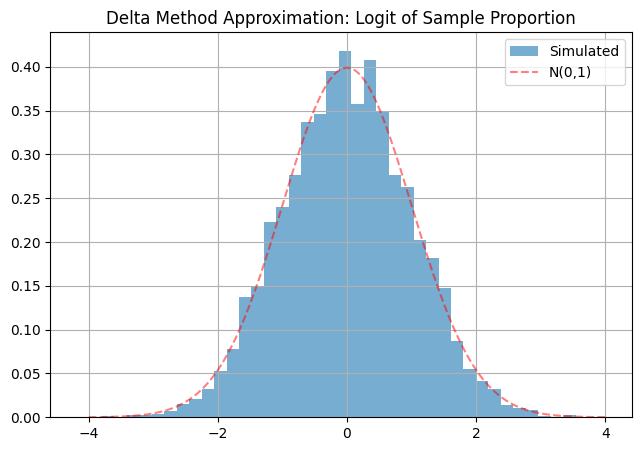

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import pi, sqrt, exp
import warnings

"""
Set simulation parameters:
- n = 1000 sample size
- rep = 10,000 draws
- theta = 0.5 true parameter value
"""
np.random.seed(0)
n = 10_000
rep = 10_000
theta = 0.5

#Logit function: g(p) = logit(p)
def logit(p):
    """
    Logit function.
    Args:
      p: float
    Returns:
      logit(p): float
    """
    return np.log(p/(1-p))


#Function for g'(p)
def dlogit(p):
    """
    First derivative of logit function.
    Args:
      p: float
    Returns:
      1/(p*(1-p)): float
    """
    return 1/(p*(1-p))

#Store logit estimates
logit_estimates = []

#Take rep draws of bernoulli samples size n
for _ in range(rep):

    #Draw n Bin(1,p)
    sample = np.random.binomial(1, theta, n)

    #Compute estimate p_hat
    p_hat = sample.mean()

    #Compute g(p_hat)
    logit_estimates.append(logit(p_hat))

#Convert logit est. to array for vecotrized calculations
logit_estimates = np.array(logit_estimates)

#Compute asymptotic variance per delta method
asymp_var = (dlogit(theta)**2 * theta*(1-theta)) / n

#Z-score logit estimates
standardized = (logit_estimates - logit(theta)) / np.sqrt(asymp_var)

#Plot histogram of estimates
plt.figure(figsize=(7.5,5))
plt.hist(standardized, bins=40, density=True, alpha=0.6, label="Simulated")

#Compare to N(0,1) density
x = np.linspace(-4, 4, 200)
plt.plot(x, 1/np.sqrt(2*np.pi)*np.exp(-x**2/2), 'r--', label="N(0,1)", alpha = 0.5)

#Plot title, grid, legend
plt.title("Delta Method Approximation: Logit of Sample Proportion")
plt.grid()
plt.legend()
plt.show()


### Ex.2: Second Order Delta Method: $g'(p)=0$

Extend the setup from (1), but let $g(p) = (p-0.5)^{2}$:

\begin{align*}
g'(p) &= 2(p-0.5) \\
g''(p) &= 2 \\
g'(0.5) &= g(p) = 0 \\
\end{align*}

Thus

$$
n ( g(\hat{p}_{n}) - g(p) )  \xrightarrow{D} p(1-p)\chi_{1}^{2}
$$

At $p=0.5$,

$$
4n \cdot g(\hat{p}_{n})  \xrightarrow{D}\chi_{1}^{2}
$$


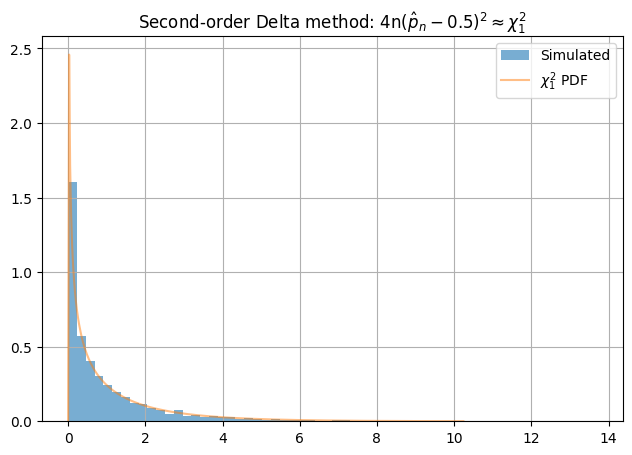

In [2]:
#2nd fn for g(p)
def g_second(p_):
    """
    g(p) = (p-0.5)^2
    Args:
      p_ : float
    Returns:
      (p_ - 0.5)**2
    """
    return (p_ - 0.5)**2

#Define PDF of ChiSq(1)
def chisq1_pdf(x):
    """
    For X ~ ChiSq(1), Chi-square(1) pdf
    Args:
      x: float
    Returns:
      1/sqrt(2*pi*x) * exp(-x/2) for x > 0
    """
    return np.where(x>0, 1.0/np.sqrt(2*pi*x) * np.exp(-x/2.0), 0.0)

#Fresh simulation, same parameters and seed
sim_vals, p = [], 0.5
for _ in range(rep):

    #n Bern(p) draws
    x = np.random.binomial(1, p, n)

    #Estimator is sample proportion
    p_hat = x.mean()

    #Limiting dist. of 4n*g(p_hat) is ChiSq(1)
    sim_vals.append(4 * n * g_second(p_hat))

#Vectorize for calculations
sim_vals = np.array(sim_vals)

# Plot histogram
plt.figure(figsize=(7.5,5))
plt.hist(sim_vals, bins=60, density=True, alpha=0.6, label="Simulated")

#Compare to ChiSq(1) PDF
xs = np.linspace(0.0, np.percentile(sim_vals, 99.9), 400)

#Suppress div by 0 warning in PDF
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    plt.plot(xs, chisq1_pdf(xs), label=r"$\chi^{2}_{1}$ PDF", alpha=0.5)

#Plot title, grid, legend
plt.title("Second-order Delta method: " + r"4n$(\hat{p}_{n}-0.5)^{2} \approx \chi^{2}_{1}$")
plt.grid()
plt.legend()
plt.show()

### Ex.3: Multivariate Delta Method

Suppose $X_{1}...X_{n} \overset{\text{iid}}{\sim} \text{MVN} \left( \theta, \Sigma  \right)$ for
$
\theta = \begin{bmatrix}
\theta_{1} \\
\theta_{2} \\
\end{bmatrix}, \Sigma = \begin{bmatrix}
1 & 0.5 \\
0.5 & 2 \\
\end{bmatrix}
$

Let $\widehat{\theta}_{n} = \bar{X}$ and $g: \mathbb{R}^{2} → \mathbb{R}^{2}$:
$$
g(\theta) = \left( \frac{\theta_{1}}{\theta_{2}},\theta_{1}\theta_{2}   \right)
$$

Per the delta method, $g(\widehat{\theta}_{n})$ has asymptotic variance:

\begin{align*}
\nabla g(\theta)^{T}n^{-1}\Sigma\nabla g(\theta) &= \begin{bmatrix}
\theta_{2}^{-1} &  \theta_{2}\\
-\theta_{1}\theta_{2}^{-2} & \theta_{1} \\
\end{bmatrix}^{T}n^{-1}\begin{bmatrix}
1 & 0.5 \\
0.5 & 2 \\
\end{bmatrix}\begin{bmatrix}
\theta_{2}^{-1} &  \theta_{2}\\
-\theta_{1}\theta_{2}^{-2} & \theta_{1} \\
\end{bmatrix} \\ \\
&= \frac{1}{n}\begin{bmatrix}
\dfrac{2\theta_{1}^{2}-\theta_{1}\theta_{2}+\theta_{2}^{2}}{\theta_{2}^{4}}
&
\displaystyle 1-\frac{2\theta_{1}^{2}}{\theta_{2}^{2}}
\\[12pt]
\displaystyle 1-\frac{2\theta_{1}^{2}}{\theta_{2}^{2}}
&
2\theta_{1}^{2}+\theta_{1}\theta_{2}+\theta_{2}^{2}
\end{bmatrix}
\end{align*}


Theoretical asymptotic variance/covariance (analytic sol'n)


array([[0.25, 0.5 ],
       [0.5 , 8.  ]])


Theoretical asymptotic variance/covariance (J.T @ Sigma @ J):


array([[0.25, 0.5 ],
       [0.5 , 8.  ]])


Empirical covariance matrix:


array([[0.25255285, 0.49646656],
       [0.49646656, 7.93536547]])

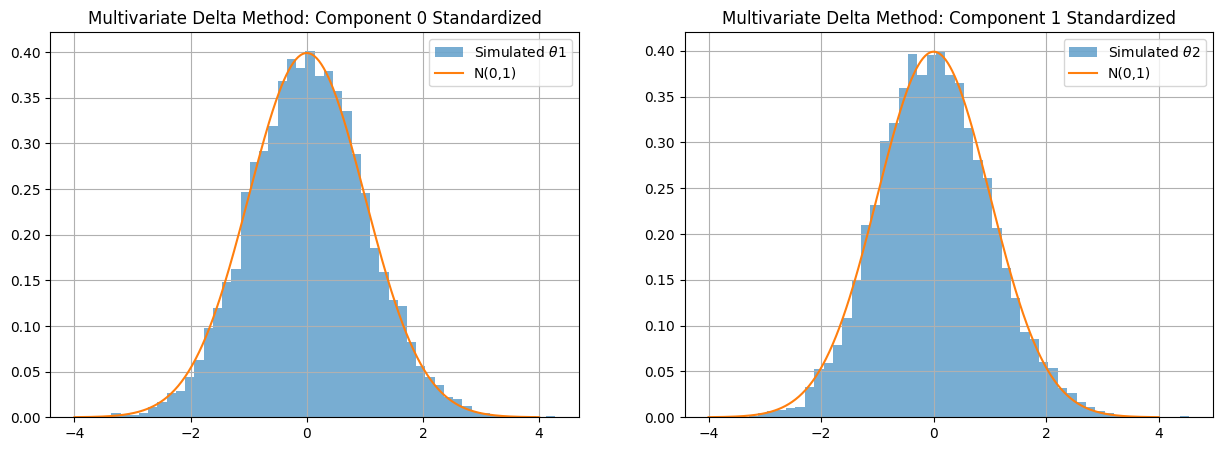

In [3]:
#Set theta = (1,2)
theta = np.array([1.0, 2.0])

#Set Sigma
Sigma = np.array([[1.0, 0.5],
                  [0.5, 2.0]])

#Simulation parameters
n = 1000
rep = 10000

#Define g(theta)
def g_vec(t):
    """
    g(theta): R^2 -> R^2
    g(theta_1, theta_2)= (theta_1/theta_2, theta_1*theta_2)
    Args:
      t: np.array(2)
    Returns:
      np.array(2)
    """
    t1, t2 = t
    return np.array([t1 / t2, t1 * t2])

#Define Jacobian using analytic solution
t1, t2 = theta
J = np.array([[1.0/t2     , t2],
              [-t1/(t2**2), t1]])

#Asymptotic var/cov of sqrt(n)(g(hat_theta)-g(theta)) matrix per delta method
V_theory = np.array([[(2*t1**2 - t1*t2 + t2**2)/(t2**4), (1 - 2*t1**2/t2**2)      ],
                     [(1- 2*t1**2/t2**2),                (2*t1**2 + t1*t2 + t2**2)]])

#Hold n^0.5(g(theta_hat) - g(theta)), a rep x 2 array
diffs = np.zeros((rep, 2))

#Generate rep sample means
for r in range(rep):

    #Draw n MVN(theta, Sigma) RVs
    x = np.random.multivariate_normal(mean=theta, cov=Sigma, size=n)

    #Estimator is sample mean (2 x 1)
    t_hat = x.mean(axis=0)
    diffs[r] = np.sqrt(n) * (g_vec(t_hat) - g_vec(theta))

#Compute empirical covariance
V_empirical = np.cov(diffs, rowvar=False)

#Compare theoretical vs empirical
print("Theoretical asymptotic variance/covariance (analytic sol'n)")
display(V_theory)
print("\nTheoretical asymptotic variance/covariance (J.T @ Sigma @ J):")
display(J.T @ Sigma @ J)
print("\nEmpirical covariance matrix:")
display(V_empirical)

#Show standardized theta_1 and theta_2 against N(0,1)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
std1 = (diffs[:,0] - 0.0)/np.sqrt(V_theory[0,0])
std2 = (diffs[:,1] - 0.0)/np.sqrt(V_theory[1,1])

#Linespace for MVN density
x_s = np.linspace(-4, 4, 400)

#Two subplots, one for theta 1 and another for theta 2
for ax, std in zip([0,1], [std1, std2]):

  #Histogram of estimates
  axs[ax].hist(std, bins=50, density=True, alpha=0.6, label=r"Simulated $\theta$"+str(ax+1))

  #N(0,1) density
  axs[ax].plot(x_s, 1/np.sqrt(2*np.pi)*np.exp(-x_s**2/2), label="N(0,1)")

  #Title, legend, grid
  axs[ax].set_title(f"Multivariate Delta Method: Component {ax} Standardized")
  axs[ax].legend()
  axs[ax].grid()

#Display plot
plt.show()